# Julia notebook to compute the solution to the frictional geostrophic equations with an unstratified fluid, a flat bottom, and a specified pressure gradient

twnh Nov '25

This notebook solves

\begin{align}
- f  v & = - \frac{\partial p}{\partial x} + \epsilon^2   \nu \frac{d^2 u}{d z^2}, \\
  f  u & = - \frac{\partial p}{\partial y} + \epsilon^2   \nu \frac{d^2 v}{d z^2} , 
\end{align}
for $u(z), v(z)$, given viscosity $\nu = \nu_0$, and boundary conditions
\begin{align}
\text{Surface~}z = 0:
\begin{cases}
\displaystyle \epsilon^2 \nu \partial_z u & = \tau^x \\
\displaystyle  \epsilon^2 \nu \partial_z v & = \tau^y 
\end{cases}
 \\
\text{Bottom~}z = -H:
\begin{cases}
u & = 0  \\
v & = 0 
\end{cases} ,
\end{align}
where $(\tau^x, \tau^y)$ is an unknown wind stress (which is computed).
The pressure $p$ is due to a specified surface pressure field $p_s(x,y)$, but no baroclinic pressure.


In [1]:
using SymPy
im = SymPy.im  # SymPy's imaginary unit
using Plots
using Statistics
notebook_name = "Example_barotropic_GeostrophicFlow_v0.2.ipynb"
using Infiltrator

### Define symbols and parameter values

In [2]:
# Geometry symbolic parameters:
z, ξ   = symbols("z ξ",   real=true, negative=true) # Vertical coordinate and source location (both in [-H,0])
x, y   = symbols("x y",   real=true)                # Horizontal coordinates
H      = SymFunction("H", real=true, positive=true) # Domain depth H(x)
geometry_params = (H(x,y), z, ξ)

# Frictional thermal wind equation symbolic parameters:
f, ϵ   = symbols("f ϵ",   real=true, positive=true) # Coriolis parameter and Ekman number
ν₀, ϕ  = symbols("ν₀ ϕ",  real=true, positive=true) # Viscosity parameters
τˣ, τʸ = symbols("τˣ τʸ", real=true)                # Surface wind stress components
τs     = symbols("τs",    complex=true)             # Complex surface wind stress
pg     = symbols("pg",    complex=true)             # Surface pressure gradient (∂/∂x + i ∂/∂y) pₛ(x,y)

# Define symbolic viscosity here:
ν = ν₀                                              # Constant viscosity profile
uv_params = (f, ϵ, ν)

# Define the parameter values
f_val  = 1
ϵ_val  = 0.95
ν₀_val = 0.06
display("Non-dimensional Ekman-layer depth:")
Ekman_depth = sqrt(2*ν₀_val/f_val)
display(Ekman_depth)

# Compute compound parameter:
ϕ_val = sqrt(f_val / ν₀_val) / ϵ_val

# Define dictionaries for substitutions:
param_values = Dict(f=>f_val, ϵ=>ϵ_val, ν₀=>ν₀_val, ϕ=>ϕ_val)

# Define specific case values here:
pₛ = SymFunction("pₛ")                               # Surface pressure function pₛ(x,y)
dpsdx_val = 0.1
Hfn = 1
case_values  = Dict(pg=>dpsdx_val, H(x, y)=>Hfn) 
display("Case values for pressure gradient and H:")
display(case_values)

"Non-dimensional Ekman-layer depth:"

0.34641016151377546

"Case values for pressure gradient and H:"

Dict{Sym{PyCall.PyObject}, Real} with 2 entries:
  pg      => 0.1
  H(x, y) => 1

### Function to solve the frictional geostrophic equation using a Green's function:

In [3]:
function compute_Guv(uv_params, geometry_params, param_values)
    # Setup symbols and parameters:
    f, ϵ, ν = uv_params
    H, z, ξ = geometry_params
    uv      = SymFunction("uv")
    A       = symbols("A",real=true)                                            # Unknown coefficient in the Green's function solution

    #0. Define the ODE for d/dz(uv(z)) = uv(z):
    ode = Eq(-im * f * uv(z) + ϵ^2 * diff(diff(ν * uv(z),z),z), 0)
    
    # 1. Solve for $G_- (z)$ on $-H \le z \le \xi$:
    Gₘ = dsolve(ode, uv(z), ics = Dict(uv(z).subs(z,-H(x,y))=>0)).rhs
    @assert simplify(ode.lhs.subs(uv(z),Gₘ)) == 0                               # Check solution
    # Replace constant names because otherwise they can interfere with the constants from the next dsolve below.
    const_names = collect([string(s) for s in Gₘ.free_symbols if occursin(r"^C\d+", string(s))])
    Gₘ = Gₘ.subs(const_names[1],A)
    @assert simplify(Gₘ.subs(z,-H(x,y))) == 0                                   # Check bottom BC

    # 2. Solve for $G_+(z)$ on  $\xi \le z \le 0$:
    Gₚ = dsolve(ode, uv(z), ics = Dict(diff(uv(z),z).subs(z,0)=>0)).rhs
    @assert simplify(ode.lhs.subs(uv(z),Gₚ)) == 0                               # Check solution
    @assert simplify(diff(Gₚ,z).subs(z,0)) == 0                                 # Check surface BC

    # 3. Compute Wronskian $W(z)$:
    W = Gₘ * diff(Gₚ, z) - Gₚ * diff(Gₘ, z)

    # 4. Compute Green's function $G(z; \xi)$:
    # Gm = Gₘ * Gₚ.subs(z,ξ) / (ν.subs(z,ξ) * W.subs(z,ξ))
    # Gp = Gₘ.subs(z,ξ) * Gₚ / (ν.subs(z,ξ) * W.subs(z,ξ))
    Gm = Gₘ * Gₚ.subs(z,ξ) / (ϵ^2 *  ν.subs(z,ξ) * W.subs(z,ξ))
    Gp = Gₘ.subs(z,ξ) * Gₚ / (ϵ^2 * ν.subs(z,ξ) * W.subs(z,ξ))


    # Check continuity and jump condition:
    @assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
    @assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/(ϵ^2 * ν.subs(z,ξ)) == 0

    # #5. Define piecewise Green's function:
    G = sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ)))
    
    # Check boundary conditions:
    @assert simplify(diff(G,z).subs(z,0).subs(ξ,-H//2)) == 0
    @assert simplify(G.subs(z,-H(x,y)).subs(ξ,-H//2)) == 0

    # Final simplify (to cancel constants). Avoid simplify in general because it's not always reproducible.
    G = simplify(G)
    return G
end ;

### Compute the G's function and various manipulations of it:

In [4]:
Guv_sym = compute_Guv(uv_params,geometry_params,param_values) 
display("Full Guv(x,ξ):")
display(Guv_sym)

Guv = Guv_sym.subs(f,ϕ^2 * ϵ^2 * ν₀)
display("Simplified Guv(z,ξ)")
display(Guv)

Guv0 = Guv.subs(ξ,0)
display("Simplified Guv(z,0)")
display(Guv0)

tmp  = diff(Guv, z)
tmp2 = tmp.subs(z, -H(x,y))
dGuv_dz_at_bottom = tmp2.args[1].args[1]
display("Simplified d/dz Guv(z,ξ) @ z = -H(x,y)")
display(dGuv_dz_at_bottom)
display("Simplified d/dz Guv(z,0) @ z = -H(x,y)")
display(dGuv_dz_at_bottom.subs(ξ,0))

tmp = integrate(expand(Guv), (z, -H(x,y), 0)).args[1].args[1]
max_obj = sympy.Max(ξ, -H(x, y))
Guv_int_wrt_z = tmp.subs(max_obj, ξ)
display("Simplified integral Guv(z,ξ) wrt z = -H(x,y) to 0")
display(factor(Guv_int_wrt_z))

Guv_int_wrt_z0 = Guv_int_wrt_z.subs(ξ,0)
display("Simplified integral Guv(z,ξ) wrt z = -H(x,y) to 0 @ ξ = 0")
display(simplify(Guv_int_wrt_z0))
tmp = integrate(expand(Guv), (ξ, -H(x,y), 0)).args[1].args[1]
max_obj = sympy.Max(z, -H(x, y))
Guv_int_wrt_ξ = tmp.subs(max_obj, z)
display("Simplified integral Guv(z,ξ) wrt ξ = -H(x,y) to 0")
display(simplify(factor(Guv_int_wrt_ξ)))

𝔲1 = Guv_int_wrt_ξ * pg
display("Pressure-driven flow field 𝔲₁(x,y,z):")
display(simplify(𝔲1))

𝔲2 = - Guv0 * τs 
display("Stress-driven   flow field 𝔲₂(x,y,z):")
display(simplify(𝔲2))
𝔲 = 𝔲1 + 𝔲2

tmp = integrate(expand(Guv_int_wrt_ξ),(z,-H(x,y),0))
𝔘1 = (tmp.args[1] + tmp.args[2].args[1].args[1])*pg
display("Pressure-driven flow field 𝔘₁(x,y):")
display(simplify(𝔘1))

𝔘2 = - Guv_int_wrt_z0 * τs 
display("Stress-driven   flow field 𝔘₂(x,y):")
display(simplify(𝔘2))
𝔘 = 𝔘1 + 𝔘2
tmp    = integrate(𝔲,(z,-H(x, y),0))
int_𝔲  = tmp.args[1] + tmp.args[2].args[1].args[1]
res    = int_𝔲 - 𝔘
@assert res == 0

τb1 = - ϵ^2 * ν * (integrate(expand(dGuv_dz_at_bottom),(ξ,-H(x,y),0)).args[1].args[1]) * pg
display("Pressure-driven bottom stress on fluid -ν ϵ^2 d/dz u(x,y,z) @ z = -H:")
display(simplify(τb1))

dGuv_dz_at_bottom_and_top = dGuv_dz_at_bottom.subs(ξ,0)
τb2 =   ϵ^2 * ν * dGuv_dz_at_bottom_and_top * τs 
display("Stress-driven   bottom stress on fluid - ν ϵ^2 d/dz u(x,y,z) @ z = -H")
display(simplify(τb2))
τb = τb1 + τb2

# Check expression for bottom stress on fluid:
tmp = - ϵ^2 * ν * diff(𝔲,z).subs(z,-H(x,y))
@assert simplify(tmp - τb) == 0

# Check expression for surface stress on fluid:
@assert simplify(diff(𝔲1,z).subs(z,0)) == 0     # Pressure-driven part of surface stress vanishes
tmp = ϵ^2 * ν * diff(𝔲,z).subs(z,0)
@assert simplify(tmp - τs) == 0

"Full Guv(x,ξ):"

/     /       ___   ___          ___   ___                      ___   ___      >
|     |   2*\/ I *\/ f *ξ    2*\/ I *\/ f *(z + H(x, y))    2*\/ I *\/ f *(z + >
|     |   ---------------    ---------------------------    ------------------ >
|     |        ____                     ____                             ____  >
| 3/2 |      \/ ν₀ *ϵ                 \/ ν₀ *ϵ                         \/ ν₀ * >
|I   *\- e                + e                            + e                   >
|----------------------------------------------------------------------------- >
|                                                     /     ___   ___          >
|                                                     | 2*\/ I *\/ f *H(x, y)  >
|                                                     | ---------------------  >
|                                                     |         ____           >
|                                        ___   ____   |       \/ ν₀ *ϵ         >
|                           

"Simplified Guv(z,ξ)"

/     /       ___            ___                        ___                    >
| 3/2 |   2*\/ I *ξ*ϕ    2*\/ I *ϕ*(z + H(x, y))    2*\/ I *ϕ*(z + ξ + H(x, y) >
|I   *\- e            + e                        + e                           >
|----------------------------------------------------------------------------- >
|                                           /     ___              \           >
|                                         2 | 2*\/ I *ϕ*H(x, y)    |           >
|                                 2*ν₀*ϕ*ϵ *\e                  + 1/           >
<                                                                              >
|     /       ___            ___                        ___                    >
| 3/2 |   2*\/ I *z*ϕ    2*\/ I *ϕ*(ξ + H(x, y))    2*\/ I *ϕ*(z + ξ + H(x, y) >
|I   *\- e            + e                        + e                           >
|----------------------------------------------------------------------------- >
|                           

"Simplified Guv(z,0)"

...

     /       ___                  ___              \
     |   2*\/ I *ϕ*H(x, y)      \/ I *ϕ*H(x, y)    |
I*τs*\- e                  + 2*e                - 1/
----------------------------------------------------
                  /     ___              \          
             2  2 | 2*\/ I *ϕ*H(x, y)    |          
         ν₀*ϕ *ϵ *\e                  + 1/          

"Pressure-driven bottom stress on fluid -ν ϵ^2 d/dz u(x,y,z) @ z = -H:"

  3/2        /  ___          \ 
-I   *pg*tanh\\/ I *ϕ*H(x, y)/ 
-------------------------------
               ϕ               

"Stress-driven   bottom stress on fluid - ν ϵ^2 d/dz u(x,y,z) @ z = -H"

        -τs          
---------------------
    /  ___          \
cosh\\/ I *ϕ*H(x, y)/

### Form final equation for $\frak{U}$:

In [5]:
lhs = im * f * 𝔘
rhs = - H(x,y)*pg - τb + τs
println()
display("Final equation linking surface pressure pₛ(x,y) to windstress:")
display(Eq(lhs, rhs))

"Final equation linking surface pressure pₛ(x,y) to windstress:"

    /   /  /                       ___                                ___      >
    |   |  |     3/2     3  2  3*\/ I *ϕ*H(x, y)      3/2     3  2  \/ I *ϕ*H( >
    |   |  \- I*I   *ν₀*ϕ *ϵ *e                  - I*I   *ν₀*ϕ *ϵ *e           >
I*f*|pg*|- ------------------------------------------------------------------- >
    |   |                                                                      >
    |   |                                                          2  6  4  4* >
    \   \                                                        ν₀ *ϕ *ϵ *e   >

>      \    ___             /                     ___                          >
> x, y)|  \/ I *ϕ*H(x, y)   |   3/2     3  2  3*\/ I *ϕ*H(x, y)      3/2     3 >
>      /*e                + \I*I   *ν₀*ϕ *ϵ *e                  + I*I   *ν₀*ϕ  >
> ---------------------------------------------------------------------------- >
>   ___                              ___                                       >
> \/ I *ϕ*H(x, y)       2  

### Solve for windstress given the pressure gradient:

In [6]:
eqn = expand(lhs - rhs)
eqn = eqn.subs(case_values)
sol = solve(Eq(eqn,0), τs)[1]
sol_num = float(numerator(  sol).subs(param_values).n())
sol_den = float(denominator(sol).subs(param_values).n())
τs_val = float(sol_num / sol_den)

-0.15278060999595106 + 0.1881511824150144im

### Solve for $\frak{u}$ and $\frak{U}$ and bottom stress:

In [7]:
𝔘_val = 𝔘.subs(case_values)
𝔘_val = 𝔘_val.subs(param_values)
𝔘_val = 𝔘_val.subs(Dict(τs=>τs_val))
Uval  = float(real(𝔘_val))
Vval  = float(imag(𝔘_val))
display("Depth-integrated flow field 𝔘(x,y):")
display(float(𝔘_val.n()))

𝔲_val = 𝔲.subs(case_values)
𝔲_val = 𝔲_val.subs(param_values)
𝔲_val = 𝔲_val.subs(Dict(τs=>τs_val))
𝔲_fld(zz) = 𝔲_val.subs(z,zz).n()
N_pts = 512
zvals = range(-Hfn, 0, length=N_pts)
uvals = [𝔲_fld(z) for z in zvals]
sum_uvals = sum(uvals) * (Hfn / length(zvals))
display("Vertical sum of 𝔲(z) from z = -H to 0 with $N_pts evaluation points:")
display(sum_uvals)

τb_val = τb.subs(case_values)
τb_val = τb_val.subs(param_values)
τb_val = τb_val.subs(Dict(τs=>τs_val)).n()
display("Bottom stress on fluid - ν ϵ^2 d/dz u(x,y,z) @ z = -H:")
display(τb_val)

# Check surface and bottom stress estimates:
duvals_dz = diff(uvals) * (N_pts / Hfn)
display("Numerical bottom stress on fluid estimate:")
display(-duvals_dz[1] * (ν₀_val * ϵ_val^2))
display("Surface stress from symbolic solution ν ϵ^2 d/dz u(x,y,z) @ z = 0:")
display(τs_val)
display("Numerical surface stress on fluid estimate:")
display(duvals_dz[end] * (ν₀_val * ϵ_val^2))

# Check force balance:
@assert abs(im * f_val * float(𝔘_val) + Hfn * dpsdx_val + τb_val - τs_val) < 1e-10

"Depth-integrated flow field 𝔘(x,y):"

0.18815118241501436 + 0.25278060999595103im

"Vertical sum of 𝔲(z) from z = -H to 0 with 512 evaluation points:"

0.187887281459313 + 0.253402017259116*I

"Bottom stress on fluid - ν ϵ^2 d/dz u(x,y,z) @ z = -H:"

...

-9.80388402290829e-5 - 5.77799546958363e-10*I

"Surface stress from symbolic solution ν ϵ^2 d/dz u(x,y,z) @ z = 0:"

-0.15278060999595106 + 0.1881511824150144im

"Numerical surface stress on fluid estimate:"

-0.152061476828808 + 0.188412696160816*I

### Plot vertical profiles of $u(z), v(z)$, $U, V$, and the vector force balance: 

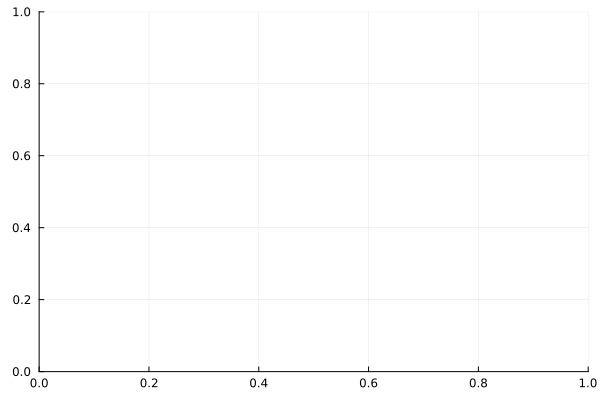

"/Users/twnh/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/Meetings/ArcticOceanDynamics_Nov25/ArcticBoundaryCurrentModel/theory/Example_barotropic_GeostrophicFlow_v0.2.ipynb_VerticalProfiles.pdf"

In [8]:
plt1 = plot()   # Start with empty plot
plot( real.(uvals), zvals, label="u(z)", lw=2, color=:blue, linestyle=:solid)
plot!(imag.(uvals), zvals, label="v(z)", lw=2, color=:red, linestyle=:solid)
plot!( [Uval, Uval], [-Hfn, 0], label="U", lw = 2, color=:blue, linestyle=:dash)
plot!( [Vval, Vval], [-Hfn, 0], label="V", lw = 2, color=:red, linestyle=:dash)
ylabel!("z")
xlabel!("Flow value")
tit_str = "\$ \\nabla p \$ = ($(round(dpsdx_val,digits=3)), 0), \$H_{Ek}\$=$(round(Ekman_depth,digits=3))"
title!("Flow \$(u(z), v(z)), (U, V)\$: " * tit_str, titlefontsize=8)
display(plt1)
savefig(notebook_name*"_VerticalProfiles.pdf")

### Plot balance of terms in the final equation:

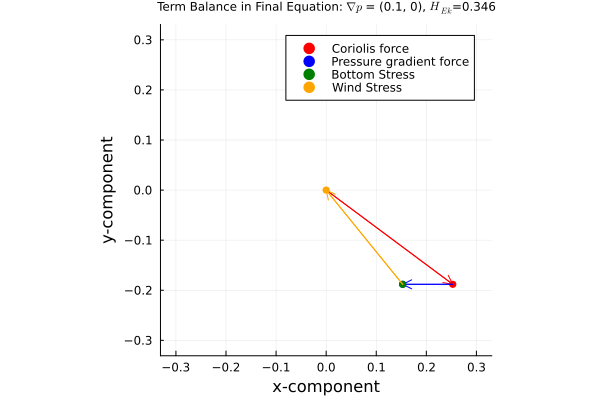

"/Users/twnh/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/Meetings/ArcticOceanDynamics_Nov25/ArcticBoundaryCurrentModel/theory/Example_barotropic_GeostrophicFlow_v0.2.ipynb_TermBalance.pdf"

In [9]:
term_names = ["Coriolis force", "Pressure gradient force", "Bottom Stress", "Wind Stress"]
terms = [-im * f_val * float(𝔘_val), -Hfn * dpsdx_val, -τb_val, τs_val]
start = [0, terms[1], terms[1] + terms[2] , terms[1] + terms[2] + terms[3]]
colors = [:red, :blue, :green, :orange]   # Assign each a color
plt2 = plot()   # Start with empty plot
max_term = float(maximum(abs.(terms)))
axis_lims = 1.05 * max_term *[ -1; 1]
for i in eachindex(terms)
    quiver!(
        [real(start[i])], [imag(start[i])],
        quiver=([real(terms[i])], [imag(terms[i])]),
        arrow=true, aspect_ratio=:equal, color=colors[i], label=term_names[i], xlims=axis_lims, ylims=axis_lims
    )
    scatter!([real(start[i] + terms[i])], [imag(start[i] + terms[i])], color=colors[i], label=term_names[i], markerstrokewidth=0)
end

plot!(legend=:topright, xlabel="x-component", ylabel="y-component", aspect_ratio=:equal, title="Term Balance in Final Equation: " * tit_str, titlefontsize=8)
display(plt2)    # Show the plot
savefig(notebook_name*"_TermBalance.pdf")

### Plot hodograph

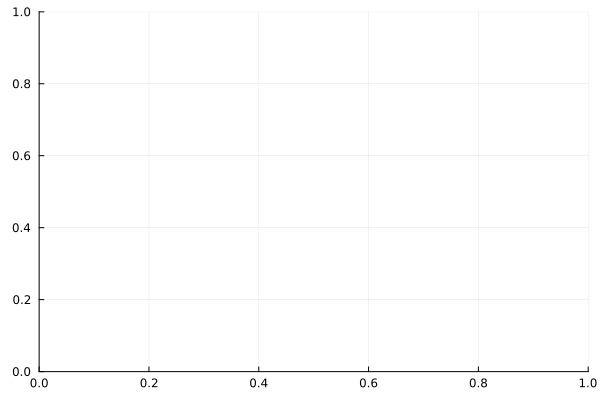

"/Users/twnh/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/Meetings/ArcticOceanDynamics_Nov25/ArcticBoundaryCurrentModel/theory/Example_barotropic_GeostrophicFlow_v0.2.ipynb_Hodograph.pdf"

In [10]:
plt3 = plot()   # Start with empty plot
plot( real.(uvals), imag.(uvals), label="(u(z),v(z))", lw=2, color=:blue, linestyle=:solid)
scatter!( [Uval], [Vval], label="(U,V)", color=:red, markerstrokewidth=0)
max_val = float(maximum(abs.([real.(uvals);imag.(uvals)])))
axis_lims = max_val*1.05*[-1; 1]
for i in N_pts:-64:1
    quiver!(
        [0.0], [0.0],
        quiver=([real(uvals[i])], [imag(uvals[i])]),
        arrow=true, aspect_ratio=:equal, xlims=axis_lims, ylims=axis_lims, color=:blue
    )
end
quiver!(
        [0.0], [0.0],
        quiver=([Uval], [Vval]),
        arrow=true, aspect_ratio=:equal, xlims=axis_lims, ylims=axis_lims, color=:red, linestyle=:dash, lw = 4
    )

plot!(legend=:bottomright, xlabel="x-component", ylabel="y-component", aspect_ratio=:equal, title="Hodograph: " * tit_str, titlefontsize=8)
display(plt3)    # Show the plot
savefig(notebook_name*"_Hodograph.pdf")